In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/sales.csv")

# Show first few rows
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (6435, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
# Basic info about dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [4]:
# Missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


In [5]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


C:\Users\asus\AppData\Local\Temp\ipykernel_7740\3024784662.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=store_sales.index, y=store_sales.values, palette="viridis")


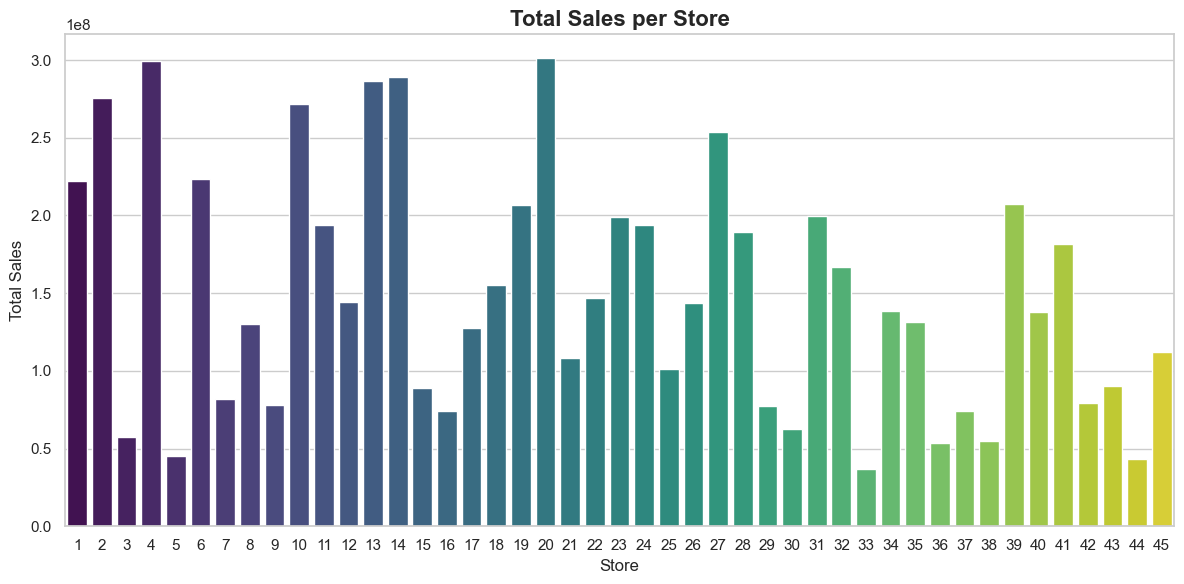

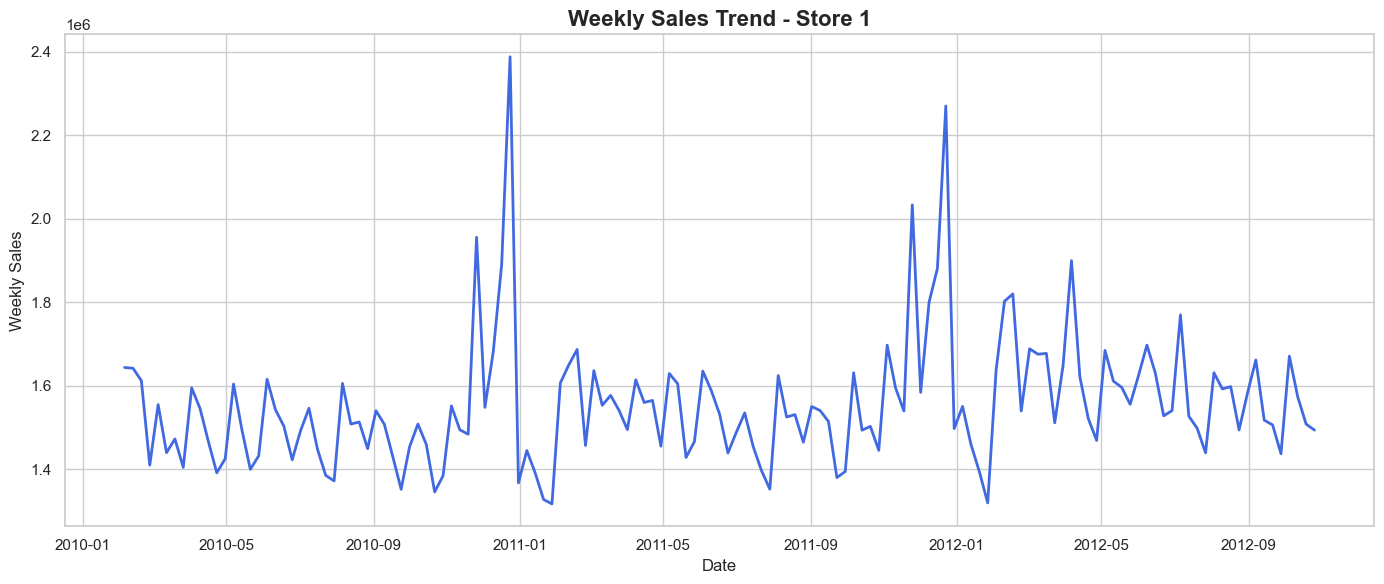

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_theme(style="whitegrid")

# -----------------------------
# 1. Total sales per store
# -----------------------------
store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=store_sales.index, y=store_sales.values, palette="viridis")
plt.title("Total Sales per Store", fontsize=16, weight='bold')
plt.xlabel("Store", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.tight_layout()
plt.show()

# -----------------------------
# 2. Weekly sales trend (Store 1)
# -----------------------------
store1 = df[df['Store'] == 1]

plt.figure(figsize=(14,6))
sns.lineplot(x='Date', y='Weekly_Sales', data=store1, color="royalblue", linewidth=2)
plt.title("Weekly Sales Trend - Store 1", fontsize=16, weight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Weekly Sales", fontsize=12)
plt.tight_layout()
plt.show()



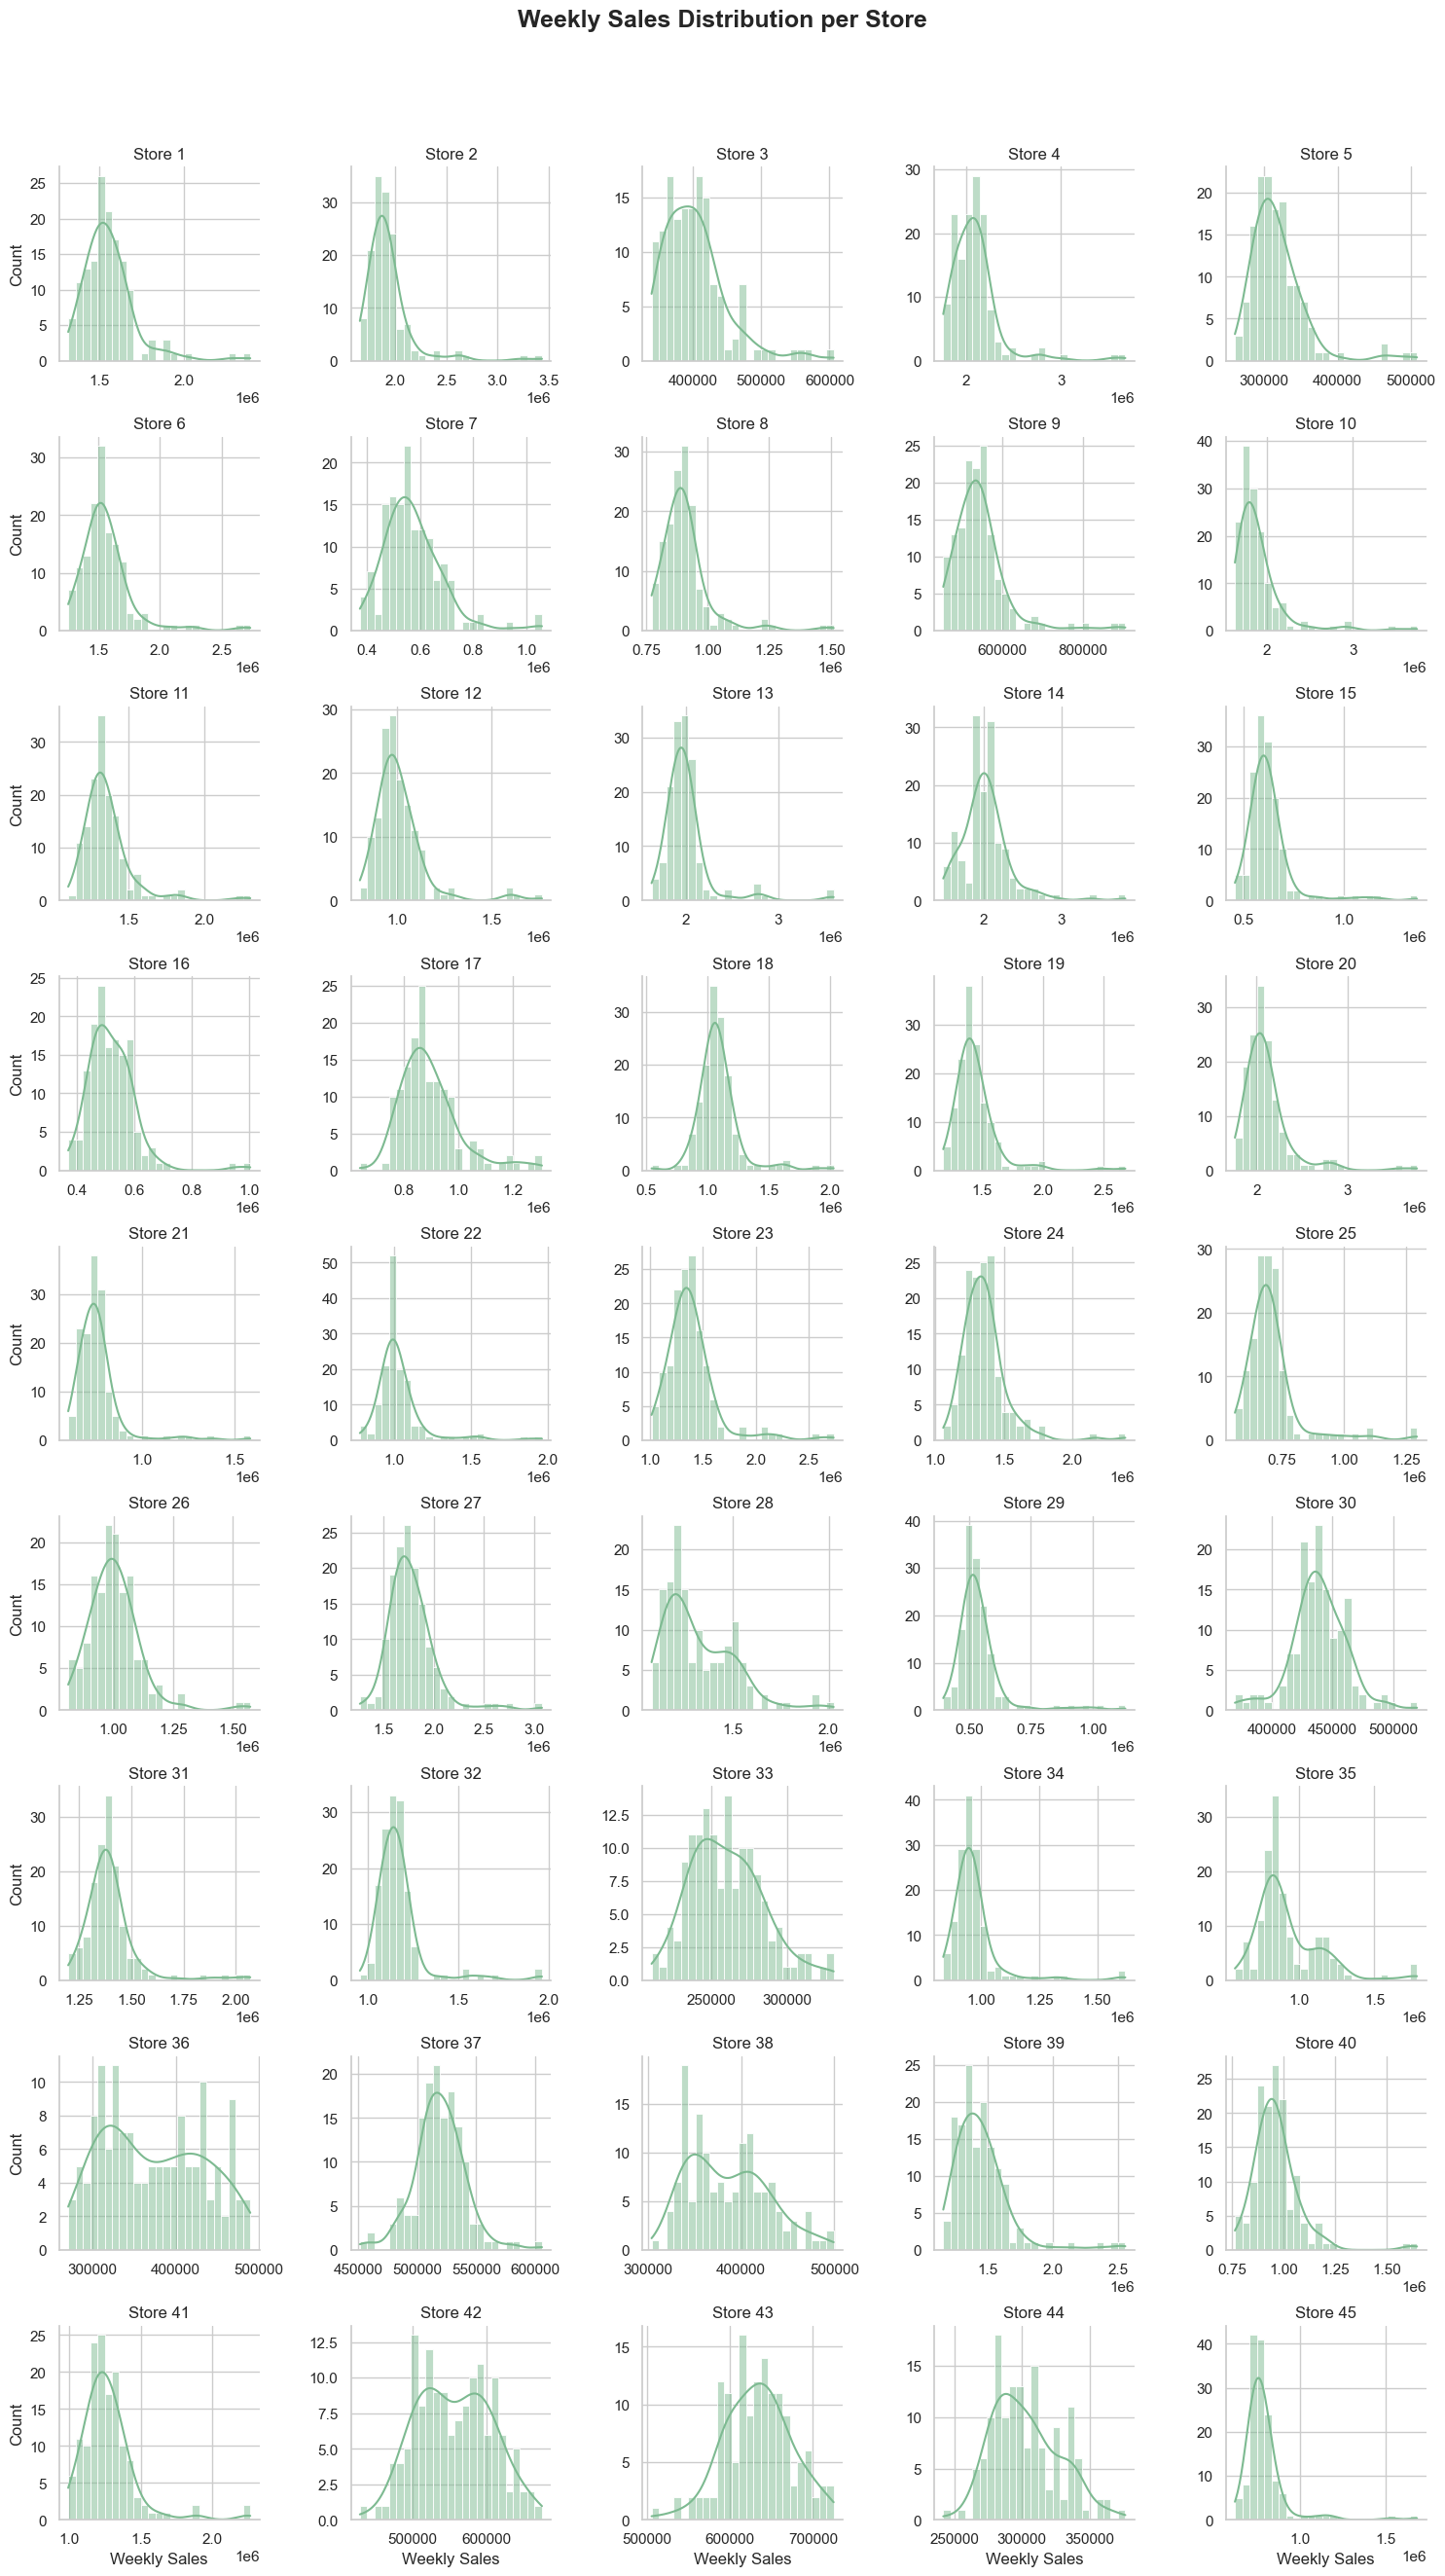

In [ ]:
#FacetGrid of sales distribution
sns.set_style("whitegrid")
sns.set_palette("crest")

g = sns.FacetGrid(
    df, 
    col="Store", 
    col_wrap=5, 
    height=3, 
    sharex=False, 
    sharey=False
)
g.map(sns.histplot, "Weekly_Sales", bins=25, kde=True)
g.set_axis_labels("Weekly Sales", "Count")
g.set_titles("Store {col_name}")

plt.subplots_adjust(top=0.92)
g.fig.suptitle(
    "Weekly Sales Distribution per Store",
    fontsize=18,
    weight="bold"
)

plt.show()


c:\Users\asus\Downloads\Sales-Forecasting-Retail\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\asus\Downloads\Sales-Forecasting-Retail\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\asus\Downloads\Sales-Forecasting-Retail\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


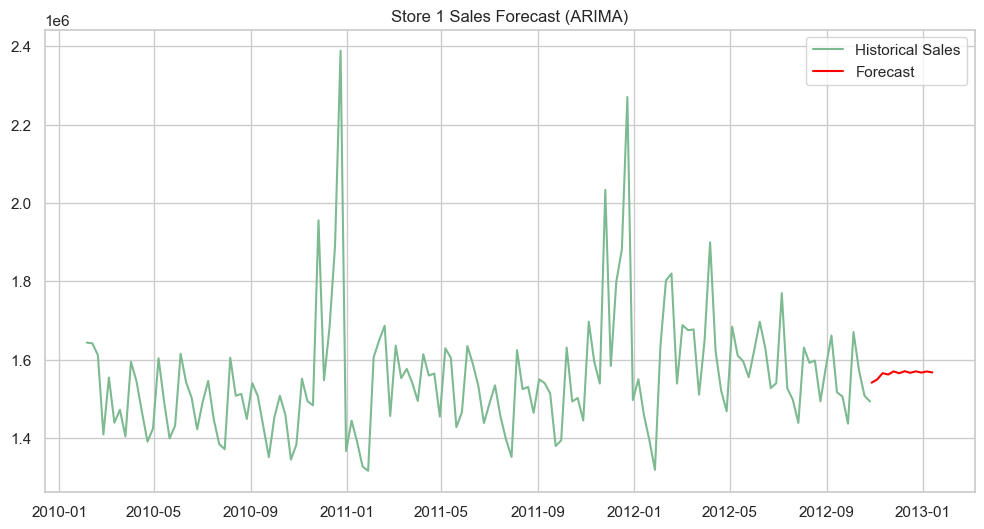

In [18]:
from statsmodels.tsa.arima.model import ARIMA

# Select store 1 sales
store1 = df[df['Store'] == 1].sort_values('Date')
ts = store1.set_index('Date')['Weekly_Sales']

# Fit ARIMA model
model = ARIMA(ts, order=(2,1,2))  # (p,d,q) parameters
model_fit = model.fit()

# Forecast next 12 weeks
forecast = model_fit.forecast(steps=12)

# Plot
plt.figure(figsize=(12,6))
plt.plot(ts, label="Historical Sales")
plt.plot(pd.date_range(ts.index[-1], periods=12, freq='W'), forecast, label="Forecast", color='red')
plt.legend()
plt.title("Store 1 Sales Forecast (ARIMA)")
plt.show()


In [ ]:
# Feature Engineering
# Convert 'Date' to datetime 
# Create new features
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df['Year'] = df['Date'].dt.year
df['Day'] = df['Date'].dt.day

# Lag features (previous week sales)
df['Lag_1'] = df.groupby('Store')['Weekly_Sales'].shift(1)
df['Lag_2'] = df.groupby('Store')['Weekly_Sales'].shift(2)

# Rolling average (last 4 weeks sales)
df['Rolling_4'] = df.groupby('Store')['Weekly_Sales'].shift(1).rolling(4).mean()

df.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Week,Year,Day,Lag_1,Lag_2,Rolling_4
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2,5,2010,5,NaN,NaN,NaN
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2,6,2010,12,1643690.90,NaN,NaN
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2,7,2010,19,1641957.44,1643690.90,NaN
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2,8,2010,26,1611968.17,1641957.44,NaN
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,3,9,2010,5,1409727.59,1611968.17,1576836.025


In [27]:
# Split data into train and test sets
# Assuming 'Year' is the column for year and we want to predict 2012 sales
# Example: Store 1 only
store1 = df[df['Store'] == 1].dropna()

train = store1[store1['Year'] < 2012]
test = store1[store1['Year'] == 2012]

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)


Train Shape: (96, 15)
Test Shape: (43, 15)


RMSE: 112904.62455086566
MAE: 84697.6853488372


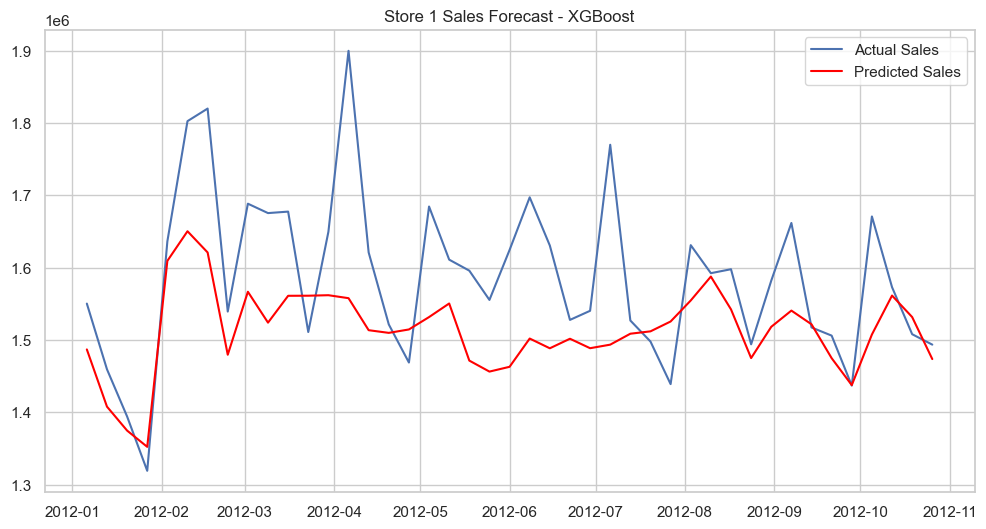

In [29]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Features and target
features = ['Month', 'Week', 'Lag_1', 'Lag_2', 'Rolling_4']
target = 'Weekly_Sales'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# Train XGBoost
model = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Manual RMSE
mae = mean_absolute_error(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

# Plot
plt.figure(figsize=(12,6))
plt.plot(test['Date'], y_test, label="Actual Sales")
plt.plot(test['Date'], y_pred, label="Predicted Sales", color="red")
plt.legend()
plt.title("Store 1 Sales Forecast - XGBoost")
plt.show()



c:\Users\asus\Downloads\Sales-Forecasting-Retail\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 169ms/step - loss: 0.0709 - val_loss: 0.0475
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0548 - val_loss: 0.0276
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0374 - val_loss: 0.0079
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0261 - val_loss: 0.0080
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0302 - val_loss: 0.0053
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0265 - val_loss: 0.0054
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0268 - val_loss: 0.0063
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0269 - val_loss: 0.0058
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0270 - val_loss: 0.0053
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0267 - val_loss: 0.0053
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0269 - val_loss: 0.0059
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0267 - val_loss: 0.0058


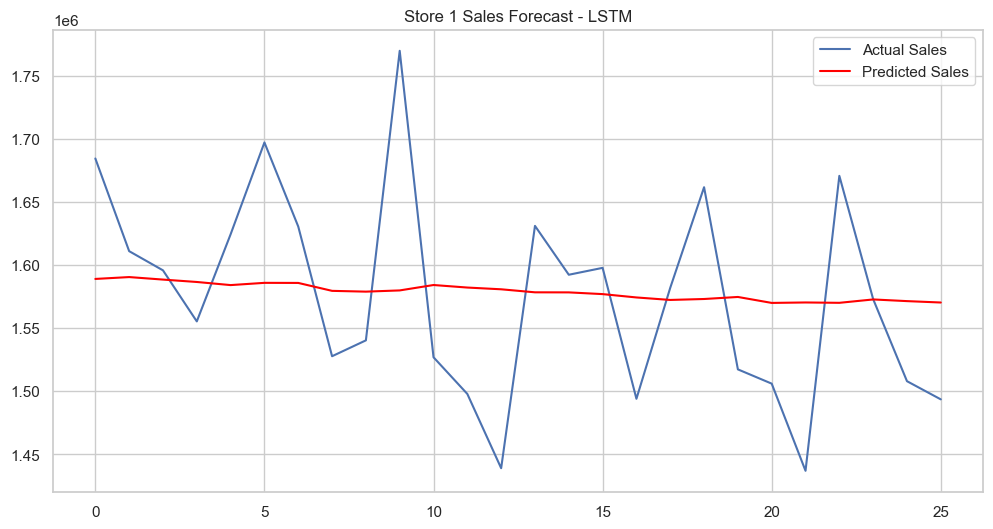

In [48]:
# LSTM Model for Store 1 Sales Forecasting
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1️⃣ Select store 1 and drop missing values
store1 = df[df['Store'] == 1].dropna()

# 2️⃣ Extract sales values and ensure numeric
sales = store1[['Weekly_Sales']].values.astype(np.float32)

# 3️⃣ Scale values between 0 and 1
scaler = MinMaxScaler()
sales_scaled = scaler.fit_transform(sales)

# 4️⃣ Create sequences for LSTM
def create_sequences(data, time_steps=10):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps, 0])
        y.append(data[i+time_steps, 0])
    return np.array(X), np.array(y)

time_steps = 10
X, y = create_sequences(sales_scaled, time_steps)

# 5️⃣ Reshape for LSTM [samples, timesteps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))
y = y.reshape(-1, 1)

# 6️⃣ Train/test split (80/20)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 7️⃣ Build LSTM model
model = Sequential()
model.add(LSTM(64, activation='relu', return_sequences=True, input_shape=(time_steps, 1)))
model.add(Dropout(0.2))
model.add(LSTM(32, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# 8️⃣ Train model
history = model.fit(X_train, y_train, epochs=20, batch_size=16,
                    validation_data=(X_test, y_test), verbose=1)

# 9️⃣ Predict
y_pred_lstm = model.predict(X_test)

# 10️⃣ Inverse scale to original sales
y_test_rescaled = scaler.inverse_transform(y_test)
y_pred_rescaled = scaler.inverse_transform(y_pred_lstm)

# 11️⃣ Compute metrics
lstm_rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
lstm_mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)

print("LSTM RMSE:", lstm_rmse)
print("LSTM MAE:", lstm_mae)

# 12️⃣ Plot results
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test_rescaled, label="Actual Sales")
plt.plot(y_pred_rescaled, label="Predicted Sales", color="red")
plt.title("Store 1 Sales Forecast - LSTM")
plt.legend()
plt.show()


In [51]:
# Train ARIMA on training data
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(y_train, order=(5,1,0))   # (p,d,q) tune if needed
arima_fit = arima_model.fit()

y_pred_arima = arima_fit.forecast(steps=len(y_test))

# Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

arima_rmse = np.sqrt(mean_squared_error(y_test, y_pred_arima))
arima_mae = mean_absolute_error(y_test, y_pred_arima)

print("ARIMA RMSE:", arima_rmse)
print("ARIMA MAE:", arima_mae)


ARIMA RMSE: 0.07816570383209377
ARIMA MAE: 0.0631650916836217


In [ ]:
# Feature Engineering
# Drop rows with NaN (created by lag/rolling features)
store1 = df[df['Store'] == 1].dropna()

# Features and target
features = ['Month', 'Week', 'Lag_1', 'Lag_2', 'Rolling_4']
target = 'Weekly_Sales'

X = store1[features].values  # 2D array
y = store1[target].values    # 1D array

# Train/test split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (111, 5)
y_train shape: (111,)


In [ ]:
# Train XGBoost model
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)

print("XGBoost RMSE:", xgb_rmse)
print("XGBoost MAE:", xgb_mae)


XGBoost RMSE: 103912.46085709856
XGBoost MAE: 85784.93285714283


In [55]:
# Assuming y_pred_arima is already predicted
arima_rmse = np.sqrt(mean_squared_error(y_test, y_pred_arima))
arima_mae = mean_absolute_error(y_test, y_pred_arima)
print("ARIMA RMSE:", arima_rmse)
print("ARIMA MAE:", arima_mae)

ARIMA RMSE: 0.07816570383209377
ARIMA MAE: 0.0631650916836217


In [ ]:
#  Comparisom=n of Model performance
results = {
    "Model": ["ARIMA", "XGBoost", "LSTM"],
    "RMSE": [arima_rmse, xgb_rmse, lstm_rmse],
    "MAE": [arima_mae, xgb_mae, lstm_mae]
}
results_df = pd.DataFrame(results)
print(results_df)

     Model           RMSE           MAE
0    ARIMA       0.078166      0.063165
1  XGBoost  103912.460857  85784.932857
2     LSTM   78509.018081  64461.839844


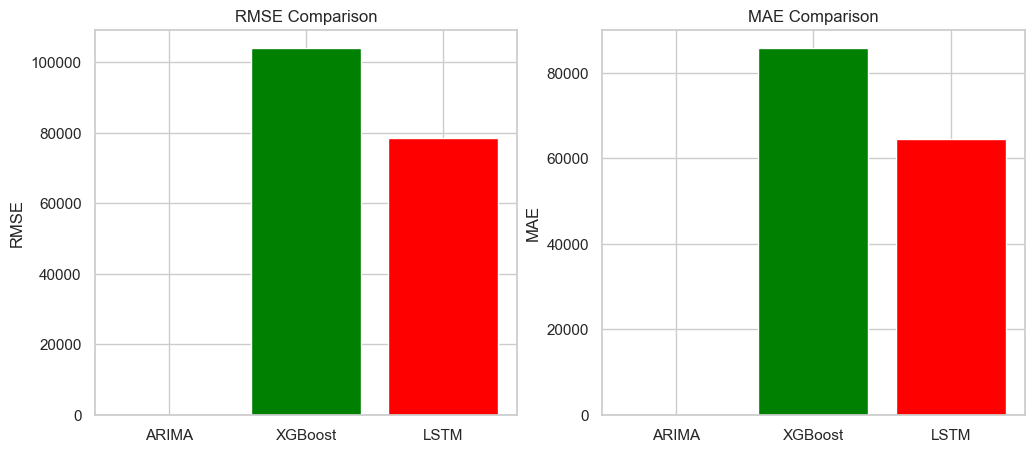

In [59]:
# Bar chart for RMSE and MAE
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# RMSE comparison
ax[0].bar(results_df["Model"], results_df["RMSE"], color=['blue','green','red'])
ax[0].set_title("RMSE Comparison")
ax[0].set_ylabel("RMSE")

# MAE comparison
ax[1].bar(results_df["Model"], results_df["MAE"], color=['blue','green','red'])
ax[1].set_title("MAE Comparison")
ax[1].set_ylabel("MAE")

plt.show()
